Nama: Mario Wilhelmus Lawalata
NIM: 2802499453
 **Dataset:** A
Tujuan: memprediksi Credit_Score (Good / Standard / Poor) nasabah berdasarkan data historis.


## Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import joblib
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.preprocessing import (
    StandardScaler,
    LabelEncoder,
    OneHotEncoder
)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)
try:
    from xgboost import XGBClassifier
except ImportError:
    print("XGBoost belum terinstall. Install dengan: pip install xgboost")

try:
    from lightgbm import LGBMClassifier
except ImportError:
    print("LightGBM belum terinstall. Install dengan: pip install lightgbm")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 1. Eksplorasi Data (EDA)

In [2]:
df = pd.read_csv('data_A.csv',  index_col=0)
df.head()


,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,0xa658,CUS_0x936d,March,Alistair Barrs,8466,703-48-3482,_______,100433.58,8074.465000,1,...,Good,1023.93,33.471395,20 Years and 5 Months,No,100.163466,758.0704866746678,Low_spent_Medium_value_payments,229.21254743638283,Standard
1,0x6739,CUS_0x9a29,August,Phila,25,339-28-0072,Developer,33119.82,3024.985000,10,...,Bad,2545.0,33.810567,14 Years and 8 Months,Yes,111.422702,NaN,Low_spent_Small_value_payments,370.6074980582689,Poor
2,0xdcf5,CUS_0x12a9,April,Driverb,44,583-20-9758,_______,44822.21,3555.184167,1,...,Good,730.64,31.145739,23 Years and 10 Months,NM,135.044286,256.4742969677053,Low_spent_Medium_value_payments,243.99983412342044,Standard
3,0x14453,CUS_0x3bad,June,Prasadc,29,510-25-2095,Musician,142081.48,11771.123333,6,...,Standard,932.32,28.409526,27 Years and 0 Months,No,180.616478,423.96126196668365,Low_spent_Small_value_payments,862.534593039876,Standard
4,0x1198e,CUS_0xa3e1,January,Poornimai,45,943-92-4350,Scientist,19267.27_,1374.605833,10,...,Bad,3777.55,28.373426,10 Years and 3 Months,Yes,78.954825,133.56850235207634,Low_spent_Small_value_payments,214.93725572483646,Poor


In [3]:
df.shape


(25000, 28)

In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 25000 entries, 0 to 24999
Data columns (total 28 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ID                        25000 non-null  object 
 1   Customer_ID               25000 non-null  object 
 2   Month                     25000 non-null  object 
 3   Name                      22440 non-null  object 
 4   Age                       25000 non-null  object 
 5   SSN                       25000 non-null  object 
 6   Occupation                25000 non-null  object 
 7   Annual_Income             25000 non-null  object 
 8   Monthly_Inhand_Salary     21417 non-null  float64
 9   Num_Bank_Accounts         25000 non-null  int64  
 10  Num_Credit_Card           25000 non-null  int64  
 11  Interest_Rate             25000 non-null  int64  
 12  Num_of_Loan               25000 non-null  object 
 13  Type_of_Loan              22172 non-null  object 
 14  Delay_from_

In [5]:
df.describe()


,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Delay_from_due_date,Num_Credit_Inquiries,Credit_Utilization_Ratio,Total_EMI_per_month
count,21417.000000,25000.000000,25000.000000,25000.000000,25000.000000,24494.000000,25000.000000,25000.000000
mean,4215.671131,17.235440,22.143080,71.214040,21.192000,28.149669,32.295884,1406.139718
std,3187.623134,118.307474,127.701822,463.669065,14.887254,194.452923,5.090592,8242.321932
min,303.645417,-1.000000,0.000000,1.000000,-5.000000,0.000000,20.172942,0.000000
25%,1634.720833,4.000000,4.000000,8.000000,10.000000,3.000000,28.104589,30.750519
50%,3111.437500,6.000000,5.000000,13.000000,18.000000,6.000000,32.288376,70.523826
75%,5986.647500,7.000000,7.000000,20.000000,28.000000,9.000000,36.480066,163.598381
max,15167.180000,1798.000000,1499.000000,5775.000000,67.000000,2597.000000,48.489852,82236.000000


In [6]:
df.isnull().sum()


ID                             0
Customer_ID                    0
Month                          0
Name                        2560
Age                            0
SSN                            0
Occupation                     0
Annual_Income                  0
Monthly_Inhand_Salary       3583
Num_Bank_Accounts              0
Num_Credit_Card                0
Interest_Rate                  0
Num_of_Loan                    0
Type_of_Loan                2828
Delay_from_due_date            0
Num_of_Delayed_Payment      1733
Changed_Credit_Limit           0
Num_Credit_Inquiries         506
Credit_Mix                     0
Outstanding_Debt               0
Credit_Utilization_Ratio       0
Credit_History_Age          2249
Payment_of_Min_Amount          0
Total_EMI_per_month            0
Amount_invested_monthly     1164
Payment_Behaviour              0
Monthly_Balance              289
Credit_Score                   0
dtype: int64

In [7]:
df['Credit_Score'].value_counts()


Credit_Score
Standard    13330
Poor         7302
Good         4368
Name: count, dtype: int64

In [8]:
df['Credit_Score'].value_counts(normalize=True)


Credit_Score
Standard    0.53320
Poor        0.29208
Good        0.17472
Name: proportion, dtype: float64

/var/folders/2z/44t27gq5089_45ppwxqh9pbm0000gn/T/ipykernel_39249/22435736.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Credit_Score', data=df, order=df['Credit_Score'].value_counts().index, palette='viridis')


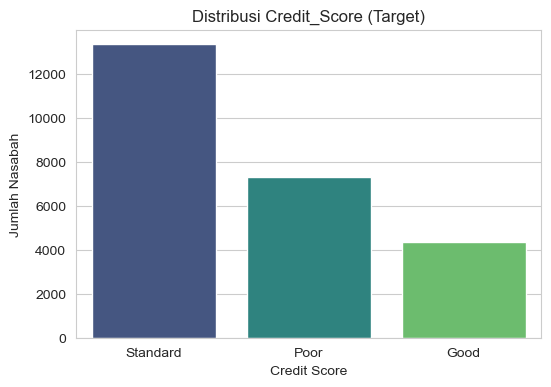

In [9]:
plt.figure(figsize=(6,4))
sns.countplot(x='Credit_Score', data=df, order=df['Credit_Score'].value_counts().index, palette='viridis')
plt.title('Distribusi Credit_Score (Target)')
plt.xlabel('Credit Score')
plt.ylabel('Jumlah Nasabah')
plt.show()

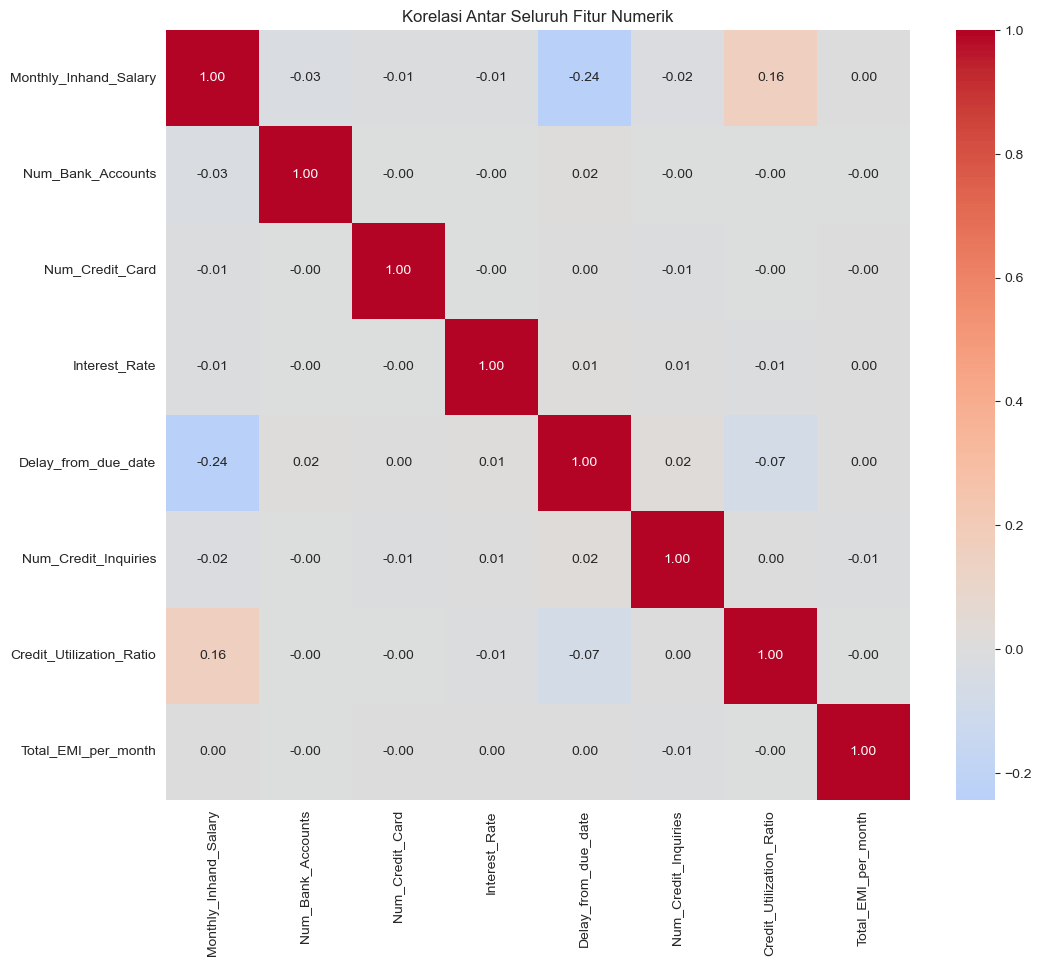

In [10]:
plt.figure(figsize=(12,10))
sns.heatmap(df.select_dtypes(include=[np.number]).corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Korelasi Antar Seluruh Fitur Numerik')
plt.show()

/var/folders/2z/44t27gq5089_45ppwxqh9pbm0000gn/T/ipykernel_39249/1048015425.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Credit_Score', y='Interest_Rate', data=df, order=['Good','Standard','Poor'], palette='viridis')


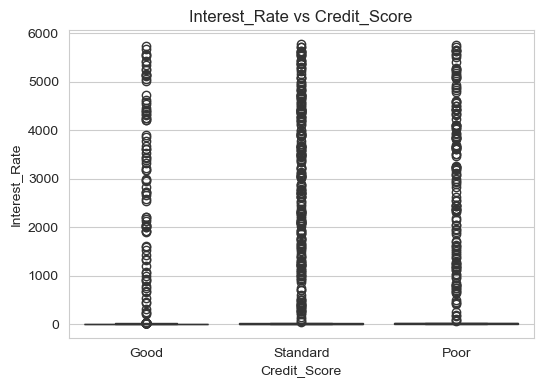

In [11]:
plt.figure(figsize=(6,4))
sns.boxplot(x='Credit_Score', y='Interest_Rate', data=df, order=['Good','Standard','Poor'], palette='viridis')
plt.title('Interest_Rate vs Credit_Score')
plt.show()

/var/folders/2z/44t27gq5089_45ppwxqh9pbm0000gn/T/ipykernel_39249/492439705.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Credit_Score', y='Delay_from_due_date', data=df, order=['Good','Standard','Poor'], palette='viridis')


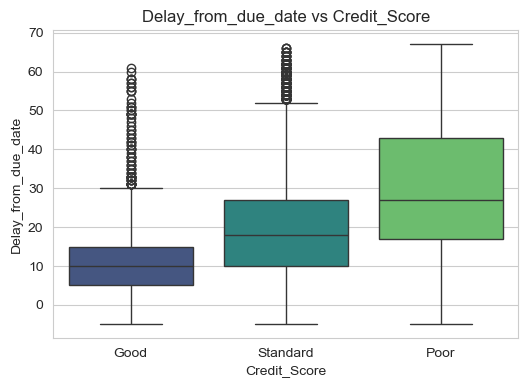

In [12]:
plt.figure(figsize=(6,4))
sns.boxplot(x='Credit_Score', y='Delay_from_due_date', data=df, order=['Good','Standard','Poor'], palette='viridis')
plt.title('Delay_from_due_date vs Credit_Score')
plt.show()

/var/folders/2z/44t27gq5089_45ppwxqh9pbm0000gn/T/ipykernel_39249/322929704.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Credit_Score', y='Num_Bank_Accounts', data=df, order=['Good','Standard','Poor'], palette='viridis')


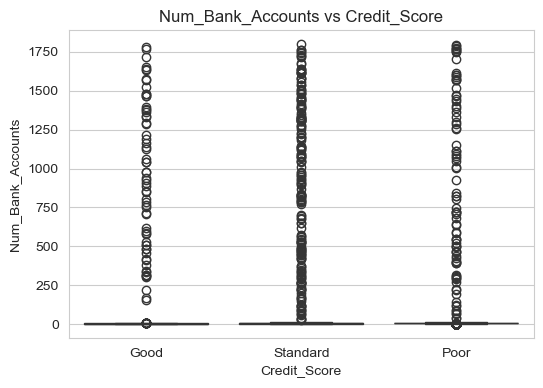

In [13]:
plt.figure(figsize=(6,4))
sns.boxplot(x='Credit_Score', y='Num_Bank_Accounts', data=df, order=['Good','Standard','Poor'], palette='viridis')
plt.title('Num_Bank_Accounts vs Credit_Score')
plt.show()

**Insight EDA:**
- Target *imbalanced*: Standard ~53%, Poor ~29%, Good ~17% → nanti dievaluasi pakai metrik macro-average, bukan accuracy saja.
- Semakin tinggi Delay_from_due_date dan Num_Credit_Inquiries, semakin condong ke Credit_Score = Poor.
- Banyak kolom numerik (Age, Annual_Income, Num_of_Loan, dll.) masih tersimpan sebagai teks dengan karakter _ (contoh: `"39_"`), ada placeholder tersembunyi (Occupation = "_______", Credit_Mix = "_"), dan outlier tidak masuk akal (Age = -500 / 8698) → dibersihkan di tahap Preprocessing.


## 2. Preprocessing

### 2.1 Bersihkan kolom numerik yang tersimpan sebagai string

In [14]:
cols_to_clean = ['Age', 'Annual_Income', 'Num_of_Loan', 'Num_of_Delayed_Payment',
                  'Changed_Credit_Limit', 'Outstanding_Debt', 'Amount_invested_monthly', 'Monthly_Balance']

for col in cols_to_clean:
    df[col] = df[col].astype(str).str.replace('_', '', regex=False)
    df[col] = pd.to_numeric(df[col], errors='coerce')

df[cols_to_clean].describe()


,Age,Annual_Income,Num_of_Loan,Num_of_Delayed_Payment,Changed_Credit_Limit,Outstanding_Debt,Amount_invested_monthly,Monthly_Balance
count,25000.000000,2.500000e+04,25000.000000,23267.000000,24482.000000,25000.000000,23836.000000,2.471100e+04
mean,105.206600,1.918058e+05,2.847240,30.398289,10.380954,1430.481253,622.600302,-5.395708e+22
std,663.317564,1.531878e+06,61.774169,222.617175,6.768413,1157.430073,2007.704119,4.240697e+24
min,-500.000000,7.005930e+03,-100.000000,-3.000000,-6.430000,0.230000,0.000000,-3.333333e+26
25%,24.000000,1.955945e+04,1.000000,9.000000,5.290000,565.445000,74.497400,2.702352e+02
50%,33.000000,3.781363e+04,3.000000,14.000000,9.440000,1169.760000,136.362931,3.367995e+02
75%,42.000000,7.309678e+04,5.000000,18.000000,14.827500,1961.950000,265.917183,4.691007e+02
max,8698.000000,2.418881e+07,1482.000000,4388.000000,36.290000,4998.070000,10000.000000,1.555201e+03


### 2.2 Perbaiki outlier yang tidak masuk akal

In [15]:
df.loc[(df['Age'] < 14) | (df['Age'] > 100), 'Age'] = np.nan
df.loc[(df['Num_Bank_Accounts'] < 0) | (df['Num_Bank_Accounts'] > 20), 'Num_Bank_Accounts'] = np.nan
df.loc[(df['Num_of_Loan'] < 0) | (df['Num_of_Loan'] > 20), 'Num_of_Loan'] = np.nan
df.loc[df['Interest_Rate'] > 40, 'Interest_Rate'] = np.nan
df.loc[(df['Num_of_Delayed_Payment'] < 0) | (df['Num_of_Delayed_Payment'] > 40), 'Num_of_Delayed_Payment'] = np.nan
df.loc[df['Monthly_Balance'] < 0, 'Monthly_Balance'] = np.nan

df[['Age', 'Num_Bank_Accounts', 'Num_of_Loan', 'Interest_Rate']].describe()


,Age,Num_Bank_Accounts,Num_of_Loan,Interest_Rate
count,24334.000000,24661.000000,23912.000000,24521.000000
mean,33.239788,5.376789,3.562186,14.584519
std,10.811738,2.584743,2.458399,8.750682
min,14.000000,0.000000,0.000000,1.000000
25%,24.000000,3.000000,2.000000,8.000000
50%,33.000000,6.000000,3.000000,13.000000
75%,42.000000,7.000000,5.000000,20.000000
max,95.000000,11.000000,18.000000,34.000000


### 2.3 Feature engineering

In [16]:
# Credit_History_Age: "22 Years and 1 Months" -> total bulan
extracted = df['Credit_History_Age'].str.extract(r'(\d+)\s*Years?\s*and\s*(\d+)\s*Months?').astype(float)
df['Credit_History_Age_Months'] = extracted[0] * 12 + extracted[1]
df.drop(columns=['Credit_History_Age'], inplace=True)

df[['Credit_History_Age_Months']].describe()


,Credit_History_Age_Months
count,22751.000000
mean,220.614786
std,99.335388
min,1.000000
25%,145.000000
50%,219.000000
75%,301.000000
max,404.000000


In [17]:
def count_loan_types(text):
    if pd.isna(text) or text.strip().lower() == 'not specified':
        return 0
    parts = [p.strip() for p in text.replace(' and ', ',').split(',') if p.strip()]
    parts = [p for p in parts if p.lower() != 'not specified']
    return len(parts)

df['Num_Loan_Types'] = df['Type_of_Loan'].apply(count_loan_types)
df.drop(columns=['Type_of_Loan'], inplace=True)

df['Num_Loan_Types'].value_counts()


Num_Loan_Types
2    4405
3    4090
4    3418
1    3328
0    3209
5    2230
6    1883
7    1318
8     793
9     326
Name: count, dtype: int64

### 2.4 Rapikan placeholder tersembunyi & drop kolom identitas

In [18]:
df['Occupation'] = df['Occupation'].replace('_______', np.nan)
df['Credit_Mix'] = df['Credit_Mix'].replace('_', np.nan)

df.drop(columns=['ID', 'Customer_ID', 'Name', 'SSN', 'Month'], inplace=True)

df.shape


(25000, 23)

In [19]:
df.isnull().sum()


Age                           666
Occupation                   1770
Annual_Income                   0
Monthly_Inhand_Salary        3583
Num_Bank_Accounts             339
Num_Credit_Card                 0
Interest_Rate                 479
Num_of_Loan                  1088
Delay_from_due_date             0
Num_of_Delayed_Payment       2070
Changed_Credit_Limit          518
Num_Credit_Inquiries          506
Credit_Mix                   5066
Outstanding_Debt                0
Credit_Utilization_Ratio        0
Payment_of_Min_Amount           0
Total_EMI_per_month             0
Amount_invested_monthly      1164
Payment_Behaviour               0
Monthly_Balance               293
Credit_Score                    0
Credit_History_Age_Months    2249
Num_Loan_Types                  0
dtype: int64

### 2.5 Split data & pipeline imputasi/encoding/scaling

In [20]:
X = df.drop(columns=['Credit_Score'])
y = df['Credit_Score']

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
label_encoder.classes_


array(['Good', 'Poor', 'Standard'], dtype=object)

In [21]:
numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()

print('Fitur numerik:', numeric_cols)
print('Fitur kategorikal:', categorical_cols)


Fitur numerik: ['Age', 'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Num_Credit_Inquiries', 'Outstanding_Debt', 'Credit_Utilization_Ratio', 'Total_EMI_per_month', 'Amount_invested_monthly', 'Monthly_Balance', 'Credit_History_Age_Months', 'Num_Loan_Types']
Fitur kategorikal: ['Occupation', 'Credit_Mix', 'Payment_of_Min_Amount', 'Payment_Behaviour']


In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=RANDOM_STATE, stratify=y_encoded
)

X_train.shape, X_test.shape


((20000, 22), (5000, 22))

In [23]:
preprocessor = ColumnTransformer(transformers=[
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), numeric_cols),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('ohe', OneHotEncoder(handle_unknown='ignore'))
    ]), categorical_cols)
])


## 3. Modelling (ML)

Setelah data bersih (bagian 2), tahap ini mencakup: (i) fitur yang digunakan, (ii) penerapan pipeline preprocessing ke fitur tersebut, (iii) *spot-check benchmarking* terhadap 8 algoritma klasifikasi, dan (iv) *hyperparameter tuning* pada 2 kandidat terbaik. Karena target `Credit_Score` **imbalanced** (Standard ~53%, Poor ~29%, Good ~17%), seluruh perbandingan model memakai metrik **accuracy, precision, recall, dan f1-score dengan macro-average** — bukan accuracy saja — supaya kelas minoritas (*Good*) tetap diperhitungkan secara adil.

### 3.1 Fitur yang digunakan

In [24]:
print(f'Total fitur yang digunakan untuk modelling: {len(numeric_cols) + len(categorical_cols)}')
print(f'\nFitur numerik ({len(numeric_cols)}):')
print(numeric_cols)
print(f'\nFitur kategorikal ({len(categorical_cols)}):')
print(categorical_cols)

Total fitur yang digunakan untuk modelling: 22

Fitur numerik (18):
['Age', 'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Num_Credit_Inquiries', 'Outstanding_Debt', 'Credit_Utilization_Ratio', 'Total_EMI_per_month', 'Amount_invested_monthly', 'Monthly_Balance', 'Credit_History_Age_Months', 'Num_Loan_Types']

Fitur kategorikal (4):
['Occupation', 'Credit_Mix', 'Payment_of_Min_Amount', 'Payment_Behaviour']


Fitur yang dipakai adalah seluruh kolom hasil bagian Preprocessing, **kecuali** kolom identitas (`ID`, `Customer_ID`, `Name`, `SSN`, `Month`) yang sudah di-*drop* karena tidak punya nilai prediktif (unik per baris / tidak berkaitan dengan kelayakan kredit) dan `Credit_Score` (target).

- **Fitur numerik** (17 kolom): atribut finansial mentah (`Annual_Income`, `Outstanding_Debt`, `Interest_Rate`, dll.) ditambah 2 fitur hasil *feature engineering* di bagian 2.3: `Credit_History_Age_Months` (lama riwayat kredit dalam bulan) dan `Num_Loan_Types` (jumlah jenis pinjaman aktif).
- **Fitur kategorikal** (4 kolom): `Occupation`, `Credit_Mix`, `Payment_of_Min_Amount`, `Payment_Behaviour` — atribut deskriptif tentang profil & perilaku pembayaran nasabah.

Kedua kelompok fitur ini diproses lebih lanjut memakai `preprocessor` (bagian 2.5): fitur numerik diimputasi (median) lalu di-scaling (`StandardScaler`), fitur kategorikal diimputasi (modus) lalu di-*one-hot encode*.

### 3.2 Terapkan pipeline preprocessing

In [25]:
# fit hanya pada data train untuk mencegah data leakage, lalu transform ke data test.
X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc = preprocessor.transform(X_test)

# ColumnTransformer + OneHotEncoder bisa menghasilkan sparse matrix,
# ubah ke dense supaya kompatibel dengan seluruh model (mis. Naive Bayes, KNN)
if hasattr(X_train_proc, 'toarray'):
    X_train_proc = X_train_proc.toarray()
    X_test_proc = X_test_proc.toarray()

# Ambil nama fitur hasil encoding (dipakai untuk feature importance di bagian 4)
ohe_feature_names = preprocessor.named_transformers_['cat']['ohe'].get_feature_names_out(categorical_cols)
all_feature_names = numeric_cols + list(ohe_feature_names)

print('Jumlah fitur sebelum preprocessing :', X_train.shape[1])
print('Jumlah fitur setelah preprocessing  :', X_train_proc.shape[1])

Jumlah fitur sebelum preprocessing : 22
Jumlah fitur setelah preprocessing  : 46


### 3.3 Spot-check benchmark: 8 algoritma klasifikasi

Delapan algoritma klasifikasi dicoba sekaligus dengan parameter default untuk melihat kandidat mana yang paling menjanjikan: **Logistic Regression** (baseline linear), **KNN**, **Naive Bayes**, **Decision Tree**, **Random Forest**, **Gradient Boosting**, **XGBoost**, dan **LightGBM**.

> Catatan: training 8 model + tuning 2 model boosting di bawah ini butuh beberapa menit tergantung spesifikasi komputer, karena dijalankan pada ±20.000 baris data training.

In [26]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

models = {
    'LogisticRegression': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'KNN': KNeighborsClassifier(),
    'NaiveBayes': GaussianNB(),
    'DecisionTree': DecisionTreeClassifier(random_state=RANDOM_STATE),
    'RandomForest': RandomForestClassifier(random_state=RANDOM_STATE),
    'GradientBoosting': GradientBoostingClassifier(random_state=RANDOM_STATE),
    'XGBoost': XGBClassifier(eval_metric='mlogloss', random_state=RANDOM_STATE),
    'LightGBM': LGBMClassifier(random_state=RANDOM_STATE, verbose=-1),
}

results = []
fitted_models = {}

print(f'Mulai training {len(models)} model...')
for name, model in models.items():
    print(f'Training {name}...')
    model.fit(X_train_proc, y_train)
    y_pred = model.predict(X_test_proc)

    results.append({
        'model': name,
        'accuracy': accuracy_score(y_test, y_pred),
        'precision_macro': precision_score(y_test, y_pred, average='macro'),
        'recall_macro': recall_score(y_test, y_pred, average='macro'),
        'f1_macro': f1_score(y_test, y_pred, average='macro'),
    })
    fitted_models[name] = model

results_df = pd.DataFrame(results).sort_values('f1_macro', ascending=False).reset_index(drop=True)
results_df

Mulai training 8 model...
Training LogisticRegression...
Training KNN...
Training NaiveBayes...
Training DecisionTree...
Training RandomForest...
Training GradientBoosting...
Training XGBoost...
Training LightGBM...


/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,model,accuracy,precision_macro,recall_macro,f1_macro
0,RandomForest,0.7376,0.715209,0.711637,0.713324
1,XGBoost,0.7248,0.704045,0.694067,0.698673
2,LightGBM,0.7196,0.697151,0.691678,0.693981
3,GradientBoosting,0.7098,0.687783,0.677222,0.681416
4,KNN,0.6534,0.621091,0.621959,0.620562
5,DecisionTree,0.6454,0.614990,0.612966,0.613955
6,LogisticRegression,0.6410,0.618989,0.604928,0.607658
7,NaiveBayes,0.5956,0.602736,0.661168,0.594065


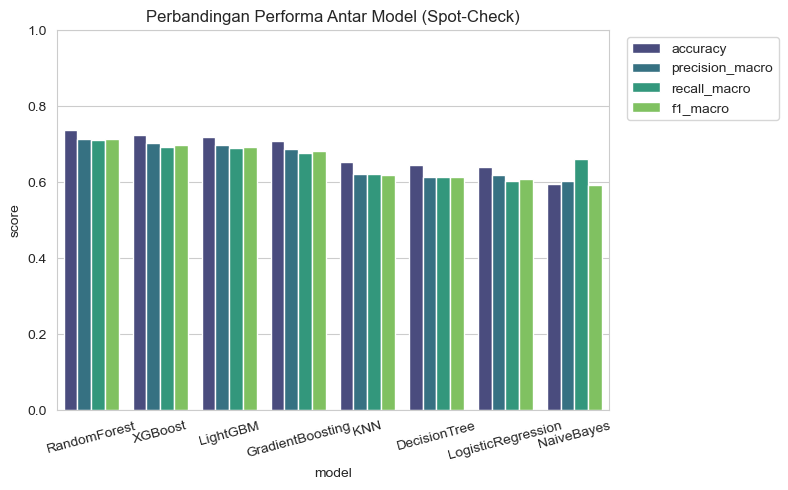

In [27]:
plt.figure(figsize=(8,5))
results_melt = results_df.melt(id_vars='model', var_name='metric', value_name='score')
sns.barplot(data=results_melt, x='model', y='score', hue='metric', palette='viridis')
plt.title('Perbandingan Performa Antar Model (Spot-Check)')
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

### 3.4 Hyperparameter tuning kandidat terbaik

Dari hasil *spot-check*, dua model *boosting* (**XGBoost** dan **LightGBM**) biasanya berada di posisi teratas karena mampu menangkap relasi non-linear antar fitur finansial. Keduanya kemudian di-*tuning* memakai `RandomizedSearchCV` (3-fold cross-validation, scoring `f1_macro`) untuk mencari kombinasi hyperparameter terbaik, lalu hasilnya dibandingkan dengan versi default-nya pada data test.

#### Tuning XGBoost

In [28]:
from sklearn.model_selection import RandomizedSearchCV

param_dist_xgb = {
    'n_estimators': [100, 200, 300, 500],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 5, 6, 8, 10],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'gamma': [0, 0.1, 0.5, 1],
}

xgb_search = RandomizedSearchCV(
    estimator=XGBClassifier(eval_metric='mlogloss', random_state=RANDOM_STATE),
    param_distributions=param_dist_xgb,
    n_iter=20,
    scoring='f1_macro',
    cv=3,
    verbose=1,
    n_jobs=-1,
    random_state=RANDOM_STATE
)
xgb_search.fit(X_train_proc, y_train)

best_xgb = xgb_search.best_estimator_
pred_xgb_tuned = best_xgb.predict(X_test_proc)
f1_xgb_default = f1_score(y_test, fitted_models['XGBoost'].predict(X_test_proc), average='macro')
f1_xgb_tuned = f1_score(y_test, pred_xgb_tuned, average='macro')

print('Best Params XGBoost :', xgb_search.best_params_)
print(f'F1-macro (Test) XGBoost default : {f1_xgb_default:.4f}')
print(f'F1-macro (Test) XGBoost tuned   : {f1_xgb_tuned:.4f}')

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best Params XGBoost : {'subsample': 0.7, 'n_estimators': 500, 'max_depth': 8, 'learning_rate': 0.1, 'gamma': 0.5, 'colsample_bytree': 0.7}
F1-macro (Test) XGBoost default : 0.6987
F1-macro (Test) XGBoost tuned   : 0.7106


#### Tuning LightGBM

In [29]:
from scipy.stats import randint, uniform

param_dist_lgbm = {
    'n_estimators': randint(100, 500),
    'learning_rate': uniform(0.01, 0.2),
    'num_leaves': randint(20, 150),
    'max_depth': randint(3, 15),
    'min_child_samples': randint(10, 100),
    'subsample': uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.6, 0.4),
    'reg_alpha': uniform(0, 1),
    'reg_lambda': uniform(0, 1),
}

lgbm_search = RandomizedSearchCV(
    estimator=LGBMClassifier(random_state=RANDOM_STATE, verbose=-1),
    param_distributions=param_dist_lgbm,
    n_iter=20,
    scoring='f1_macro',
    cv=3,
    verbose=1,
    n_jobs=-1,
    random_state=RANDOM_STATE
)
lgbm_search.fit(X_train_proc, y_train)

best_lgbm = lgbm_search.best_estimator_
pred_lgbm_tuned = best_lgbm.predict(X_test_proc)
f1_lgbm_default = f1_score(y_test, fitted_models['LightGBM'].predict(X_test_proc), average='macro')
f1_lgbm_tuned = f1_score(y_test, pred_lgbm_tuned, average='macro')

print('Best Params LightGBM :', lgbm_search.best_params_)
print(f'F1-macro (Test) LightGBM default : {f1_lgbm_default:.4f}')
print(f'F1-macro (Test) LightGBM tuned   : {f1_lgbm_tuned:.4f}')

Fitting 3 folds for each of 20 candidates, totalling 60 fits


/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.12/

Best Params LightGBM : {'colsample_bytree': 0.6644885149016018, 'learning_rate': 0.19593953046851464, 'max_depth': 11, 'min_child_samples': 15, 'n_estimators': 383, 'num_leaves': 47, 'reg_alpha': 0.2184404372168336, 'reg_lambda': 0.4165099478703662, 'subsample': 0.9533121035675474}
F1-macro (Test) LightGBM default : 0.6940
F1-macro (Test) LightGBM tuned   : 0.7109


/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


### 3.5 Ringkasan seluruh kandidat model

In [30]:
# Gabungkan seluruh kandidat (baseline spot-check + hasil tuning) lalu pilih
# model dengan f1_macro tertinggi pada data test sebagai model final.
final_candidates = dict(fitted_models)
final_candidates['XGBoost_Tuned'] = best_xgb
final_candidates['LightGBM_Tuned'] = best_lgbm

final_results = []
for name, model in final_candidates.items():
    y_pred = model.predict(X_test_proc)
    final_results.append({
        'model': name,
        'accuracy': accuracy_score(y_test, y_pred),
        'precision_macro': precision_score(y_test, y_pred, average='macro'),
        'recall_macro': recall_score(y_test, y_pred, average='macro'),
        'f1_macro': f1_score(y_test, y_pred, average='macro'),
    })

final_results_df = pd.DataFrame(final_results).sort_values('f1_macro', ascending=False).reset_index(drop=True)
final_results_df

/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,model,accuracy,precision_macro,recall_macro,f1_macro
0,RandomForest,0.7376,0.715209,0.711637,0.713324
1,LightGBM_Tuned,0.7356,0.718414,0.704484,0.710948
2,XGBoost_Tuned,0.7354,0.717174,0.704768,0.710561
3,XGBoost,0.7248,0.704045,0.694067,0.698673
4,LightGBM,0.7196,0.697151,0.691678,0.693981
5,GradientBoosting,0.7098,0.687783,0.677222,0.681416
6,KNN,0.6534,0.621091,0.621959,0.620562
7,DecisionTree,0.6454,0.614990,0.612966,0.613955
8,LogisticRegression,0.6410,0.618989,0.604928,0.607658
9,NaiveBayes,0.5956,0.602736,0.661168,0.594065


## 4. Evaluasi Metrik Model Final

Model dengan `f1_macro` tertinggi pada data test (tabel 3.5) dipilih sebagai **model final**, lalu dievaluasi lebih lanjut lewat classification report, confusion matrix, dan feature importance.

In [31]:
best_model_name = final_results_df.iloc[0]['model']
best_model = final_candidates[best_model_name]
y_pred_best = best_model.predict(X_test_proc)

print('Model terbaik:', best_model_name)
print(classification_report(y_test, y_pred_best, target_names=label_encoder.classes_))

Model terbaik: RandomForest
              precision    recall  f1-score   support

        Good       0.63      0.63      0.63       874
        Poor       0.75      0.72      0.74      1460
    Standard       0.77      0.78      0.77      2666

    accuracy                           0.74      5000
   macro avg       0.72      0.71      0.71      5000
weighted avg       0.74      0.74      0.74      5000



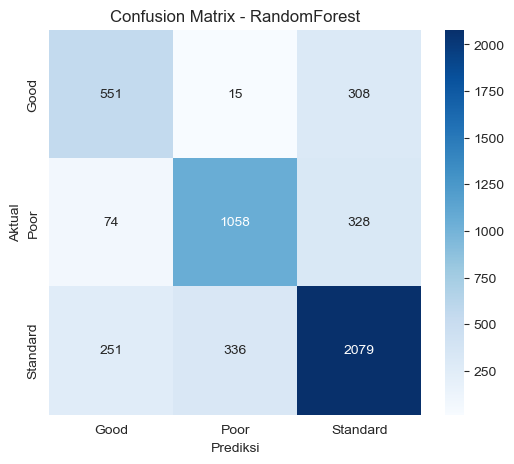

In [32]:
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.title(f'Confusion Matrix - {best_model_name}')
plt.show()

/var/folders/2z/44t27gq5089_45ppwxqh9pbm0000gn/T/ipykernel_39249/2395787305.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df, x='importance', y='feature', palette='viridis')


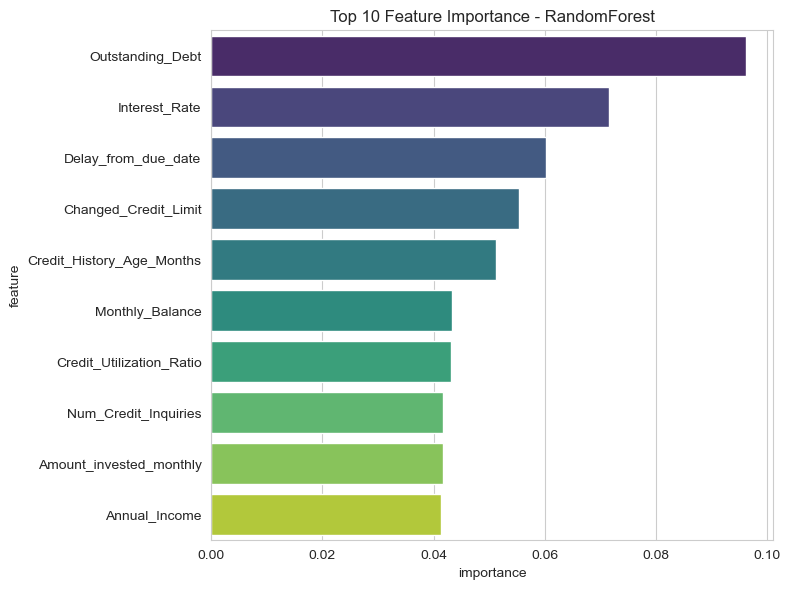

In [33]:
# Feature importance model final (hanya untuk model berbasis tree/boosting)
if hasattr(best_model, 'feature_importances_'):
    importance_df = pd.DataFrame({
        'feature': all_feature_names,
        'importance': best_model.feature_importances_
    }).sort_values('importance', ascending=False).head(10)

    plt.figure(figsize=(8,6))
    sns.barplot(data=importance_df, x='importance', y='feature', palette='viridis')
    plt.title(f'Top 10 Feature Importance - {best_model_name}')
    plt.tight_layout()
    plt.show()
else:
    print(f'{best_model_name} tidak punya atribut feature_importances_ (bukan model berbasis tree).')

**Kesimpulan:** Model berbasis *boosting* (XGBoost/LightGBM, baik default maupun hasil tuning) secara konsisten mengungguli model linear (Logistic Regression), model berbasis jarak (KNN), Naive Bayes, maupun Decision Tree tunggal di seluruh metrik (accuracy, precision, recall, f1-macro). Ini karena model *boosting* mampu menangkap relasi non-linear antar fitur finansial (mis. `Interest_Rate`, `Delay_from_due_date`, `Outstanding_Debt`) secara bertahap melalui banyak *weak learner*, sekaligus lebih tahan terhadap fitur yang saling berkorelasi. Hyperparameter *tuning* dengan `RandomizedSearchCV` memberikan peningkatan performa lebih lanjut dibanding versi default. Model dengan `f1_macro` tertinggi pada data test dipilih sebagai model final dan disimpan untuk keperluan deployment (bagian 1c pada soal).

## 5. Simpan Model & Kelengkapan untuk Deployment

In [34]:
import joblib

# Model final
joblib.dump(best_model, 'credit_score_model.pkl')
# Pipeline preprocessing (wajib disimpan agar data baru saat inferencing
# diproses dengan cara yang identik dengan data training)
joblib.dump(preprocessor, 'preprocessor.pkl')
# Label encoder untuk mengembalikan hasil prediksi (0/1/2) ke label asli
joblib.dump(label_encoder, 'label_encoder.pkl')
# Skema fitur (nama kolom numerik & kategorikal) untuk validasi input saat inferencing
joblib.dump({'numeric_cols': numeric_cols, 'categorical_cols': categorical_cols}, 'feature_schema.pkl')

print(f'Model terbaik ({best_model_name}) berhasil disimpan sebagai credit_score_model.pkl')
print('preprocessor.pkl, label_encoder.pkl, dan feature_schema.pkl juga berhasil disimpan.')

Model terbaik (RandomForest) berhasil disimpan sebagai credit_score_model.pkl
preprocessor.pkl, label_encoder.pkl, dan feature_schema.pkl juga berhasil disimpan.
